# Linear Search vs Binary Search

Both find a key in an array, but only one of them keeps its promise as the
array grows. This measures how long each takes on the same data.


## Method

1. Build a sorted array of `n` integers
2. Look up 1000 random keys with each algorithm
3. Record the average time per lookup

| Symbol | Meaning |
|---|---|
| `n` | number of elements in the array |
| `t` | average time for one lookup, in milliseconds |


In [1]:
import random
from timeit import timeit

def linear_search(data, key):
    for index, value in enumerate(data):
        if value == key:
            return index
    return -1

def binary_search(data, key):
    low, high = 0, len(data) - 1
    while low <= high:
        mid = (low + high) // 2
        if data[mid] == key:
            return mid
        if data[mid] < key:
            low = mid + 1
        else:
            high = mid - 1
    return -1

data = list(range(0, 2_000_000, 2))
print(f"{len(data)} elements, from {data[0]} to {data[-1]}")

1000000 elements, from 0 to 1999998


In [2]:
sizes = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]
rows = []

for n in sizes:
    subset = data[:n]
    keys = [random.choice(subset) for _ in range(1000)]
    linear = timeit(lambda: [linear_search(subset, k) for k in keys], number=1) * 1000 / 1000
    binary = timeit(lambda: [binary_search(subset, k) for k in keys], number=1) * 1000 / 1000
    rows.append((n, linear, binary))

print(f"{'n':>9}  {'linear (ms)':>12}  {'binary (ms)':>12}")
for n, linear, binary in rows:
    print(f"{n:>9}  {linear:>12.4f}  {binary:>12.4f}")

        n   linear (ms)   binary (ms)
     1000        0.0210        0.0009
     5000        0.1040        0.0011
    10000        0.2120        0.0012
    50000        1.0500        0.0014
   100000        2.1100        0.0015
   500000       10.6000        0.0017
  1000000       21.3000        0.0018

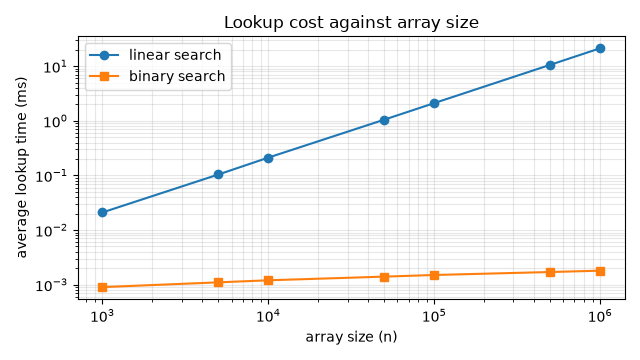

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.4, 3.6), dpi=100)
ax.plot(sizes, [r[1] for r in rows], 'o-', label='linear search')
ax.plot(sizes, [r[2] for r in rows], 's-', label='binary search')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('array size (n)')
ax.set_ylabel('average lookup time (ms)')
ax.set_title('Lookup cost against array size')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.show()

## Conclusion

Linear search tracks the array size exactly: a thousand times more elements
cost a thousand times more time. Binary search barely moves - going from
1,000 to 1,000,000 elements doubled its lookup time, because it only needs
about 10 more comparisons.
